<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/blob/main/Week02/doc/Ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score

# Implementación de código

In [8]:
# Carga del conjunto de daots Breast Cancer

df = load_breast_cancer()
X = df.data # 569x30
y = df.target # 569x1

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y eentrena el modelo de regresión lógistica
model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred_binary = (y_pred > 0.5).astype(int)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

# Presentacion de los datos

In [9]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# Correlación

In [10]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

Matriz de Confusión: [[41  2]
 [ 1 70]]


Text(0.5, 1.0, 'Matriz de Confusión')

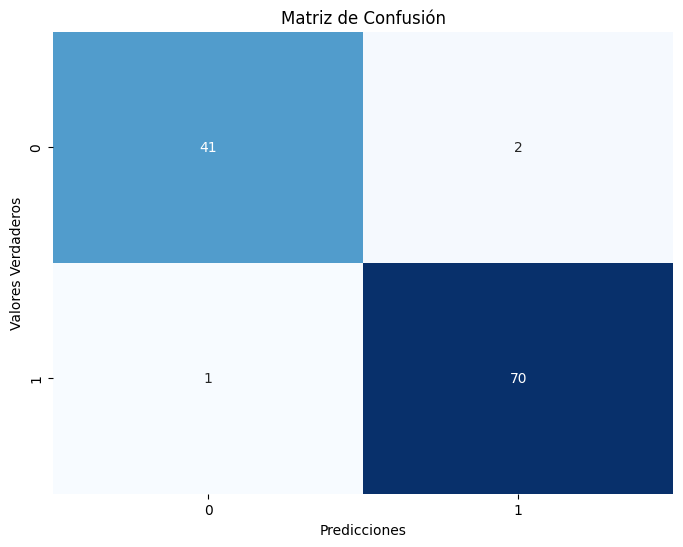

In [11]:
# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

# Métricas

In [12]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.9736842105263158


In [15]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.9859154929577465


In [16]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.9722222222222222


In [17]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.9534883720930233


In [18]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.9790209790209791


In [20]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.969701932525385


# Gráfico de ROC

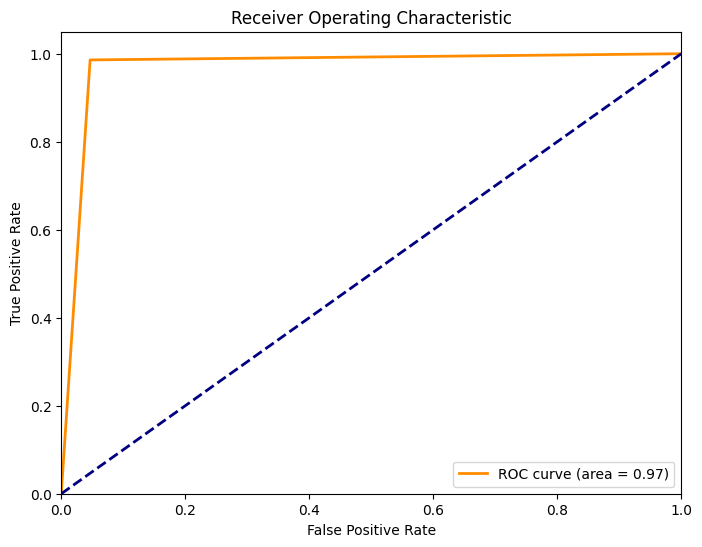

In [23]:
# Gráfico

plt.figure(figsize=(8, 6))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [25]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.8879790370127744
